In [ ]:
import pandas as pd
import numpy as np

data_df = pd.read_csv(r"C:\Users\shahh\OneDrive\Desktop\Data Science And Machine Learning\Skill_Sikshya\Day42\Advertising.csv", 
                      index_col = 0)
data_df.head(5)

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


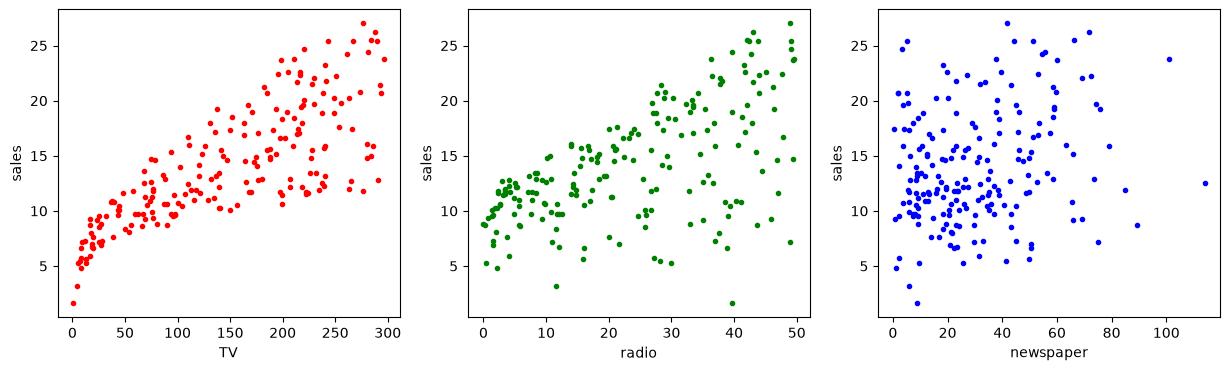

In [24]:
import matplotlib as mpl
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(15,4))
gs = mpl.gridspec.GridSpec(1,3)

# Plot of sales vs TV
ax = fig.add_subplot(gs[0])
ax.scatter(data_df["TV"], data_df["Sales"], color="red", marker=".")
ax.set_xlabel("TV")
ax.set_ylabel("sales")

# Plot of sales vs radio
ax = fig.add_subplot(gs[1])
ax.scatter(data_df["Radio"], data_df["Sales"], color="green", marker=".")
ax.set_xlabel("radio")
ax.set_ylabel("sales")

# Plot of sales vs newspaper
ax = fig.add_subplot(gs[2])
ax.scatter(data_df["Newspaper"], data_df["Sales"], color="blue", marker=".")
ax.set_xlabel("newspaper")
ax.set_ylabel("sales")

plt.show()

## Sales vs. Advertising Channels

To understand how each advertising channel relates to Sales, I plotted
separate scatter plots for TV, Radio, and Newspaper spend against Sales,
arranged side by side for easy comparison.

**Observations:**
- **TV** shows a strong, clear positive relationship with Sales — as TV
  spend increases, Sales tends to increase steadily.
- **Radio** also shows a positive relationship with Sales, though with
  more scatter (noise) than TV.
- **Newspaper** shows a weak or unclear relationship with Sales, with
  points scattered fairly randomly across the range.

These visual patterns suggest TV and Radio are likely to be stronger
predictors of Sales than Newspaper, which will be confirmed numerically
once a regression model is fit to the data.

In [25]:
X = data_df.TV.to_numpy()
y = data_df.Sales.to_numpy()

In [26]:
# Calculating beta_1

x_mean = X.mean()
y_mean = y.mean()

beta_1 = np.sum((X - x_mean) * (y - y_mean)) / np.sum(np.power((X - x_mean), 2))
print(beta_1)

0.047536640433019736


In [27]:
beta_0 = y_mean - (beta_1 * x_mean)
print(beta_0)

7.0325935491276965


In [28]:
# Best fit line equation

print(f" y = {beta_0:.2f} + {beta_1:.2f} x")

 y = 7.03 + 0.05 x


In [30]:
# Calculating SSE

y_hat = beta_0 + (beta_1 * X)

SSE = np.sum((y - y_hat)** 2)
print(SSE)

2102.5305831313512


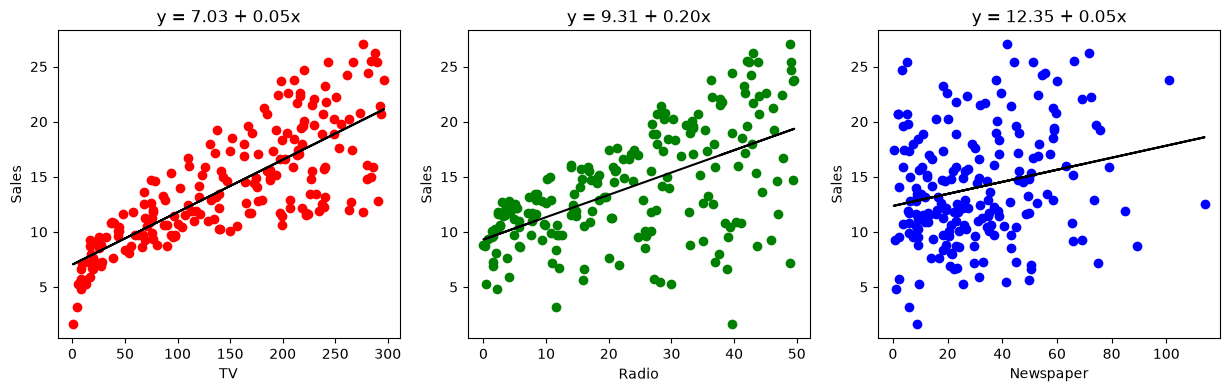

In [ ]:
import matplotlib as mpl
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(15,4))
gs = mpl.gridspec.GridSpec(1,3)

def train_plot(data_df, feature, ax, c):
    X = data_df[feature].to_numpy()
    y = data_df.Sales.to_numpy()  
    
    # Calculating beta_1
    x_mean = X.mean()
    y_mean = y.mean()
    beta_1 = np.sum((X - x_mean) * (y - y_mean)) / np.sum(np.power((X - x_mean), 2))
    
    # Calculating beta_0
    beta_0 = y_mean - (beta_1 * x_mean)
    
    y_hat = beta_0 + (beta_1 * X)
    SSE = np.sum((y - y_hat) ** 2)
    
    # Plot Regression Line
    ax.scatter(X, y, color=c)
    ax.plot(X, y_hat, color="black")
    ax.set_xlabel(feature)
    ax.set_ylabel("Sales")
    ax.set_title(f"y = {beta_0:.2f} + {beta_1:.2f}x")

ax0 = fig.add_subplot(gs[0])
train_plot(data_df, "TV", ax0, "red")

ax1 = fig.add_subplot(gs[1])
train_plot(data_df, "Radio", ax1, "green")

ax2 = fig.add_subplot(gs[2])
train_plot(data_df, "Newspaper", ax2, "blue")

plt.show()

Sklearn Implementation

In [39]:
from sklearn.linear_model import LinearRegression

In [41]:
X = data_df.TV.to_numpy()
y = data_df.Sales.to_numpy()

linear_reg = LinearRegression()


In [42]:
linear_reg.fit(X.reshape(-1,1), y.reshape(-1,1))

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[0.05]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[7.03]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1211.12]


In [43]:
# beta_0
linear_reg.intercept_

array([7.03259355])

In [44]:
# beta_1
linear_reg.coef_


array([[0.04753664]])

In [46]:
y_cap = linear_reg.predict(X.reshape(-1,1))

y_cap

array([[17.97077451],
       [ 9.14797405],
       [ 7.85022376],
       [14.23439457],
       [15.62721814],
       [ 7.44616232],
       [ 9.76595037],
       [12.74649773],
       [ 7.44140866],
       [16.53041431],
       [10.17476548],
       [17.23871025],
       [ 8.16396559],
       [11.66741599],
       [16.73482186],
       [16.32125309],
       [10.25557777],
       [20.40940417],
       [10.32212907],
       [14.03474068],
       [17.41459582],
       [18.31779199],
       [ 7.6600772 ],
       [17.88520856],
       [ 9.99412625],
       [19.52997632],
       [13.82557947],
       [18.44614092],
       [18.85970969],
       [10.38868036],
       [20.95607553],
       [12.39948025],
       [11.653155  ],
       [19.65832525],
       [11.58185004],
       [20.85149492],
       [19.72012288],
       [10.58358059],
       [ 9.08142275],
       [17.87094757],
       [16.65876324],
       [15.44657891],
       [20.98935118],
       [16.86792445],
       [ 8.22576322],
       [15

In [48]:
SSE = np.sum((y - y_cap.flatten())** 2)
SSE

np.float64(2102.5305831313512)